In [2]:
!pip install scrublet

In [3]:
!pip install anndata=='0.7.5'

In [2]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import anndata
from sklearn.cluster import KMeans
from scipy.io import mmread, mmwrite
import pandas as pd
import scrublet as scr
import pandas as pd
import seaborn as sns
import statistics
from samalg import SAM
import scanpy as sc
import seaborn as sns
import scipy.sparse
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.cluster import rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score
from Bio import SeqIO
import os

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'scrublet'

In [ ]:
#Input: STARSolo raw matrix, barcodes, and features
#Output: leiden clusters and h5ad which for some organsims are passed to SoupX.rmd (prairie vole and anole) and for others are passed to coallation (japanese quail/xenopus/zebrafish)

In [59]:
#This code is run for each new library
genome_dat = 'AC/STARSolo_NCBI/Run17_sample4_STARSoloSolo.out/GeneFull/raw/'

In [60]:
dat = sc.read_10x_mtx(genome_dat)

In [61]:
dat

AnnData object with n_obs × n_vars = 6794880 × 26523
    var: 'gene_ids', 'feature_types'

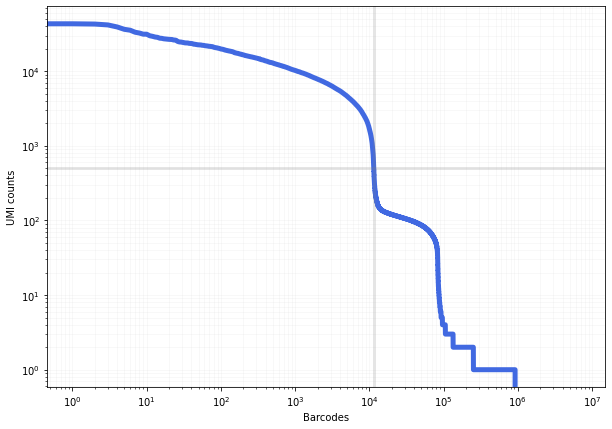

In [62]:
#Manually set UMI cutoff based on knee of plot
cutoff = 500
knee = np.sort((np.array(dat.X.sum(axis=1))).flatten())[::-1]
cell_set = np.arange(len(knee))
num_cells = cell_set[knee > cutoff][::-1][0]

fig, ax = plt.subplots(figsize=(10, 7))


ax.loglog(cell_set, knee, linewidth=5, color="#4169e1")
ax.axhline(y=cutoff, linewidth=3, color="grey", alpha = .2)


ax.axvline(x=num_cells, linewidth=3, color="grey", alpha = .2)

ax.set_xlabel("Barcodes")
ax.set_ylabel("UMI counts")

plt.grid(True, which="both", alpha = .1)
plt.show()

In [63]:
#Manually set gene cutoff (usually half of UMI cutoff)
sc.pp.filter_cells(dat, min_genes=250)
sc.pp.filter_cells(dat, min_counts=knee[num_cells])

In [64]:
#Manually set minimum cells per gene cutoff 
sc.pp.filter_genes(dat, min_cells=3)

In [65]:
dat

AnnData object with n_obs × n_vars = 11441 × 23393
    obs: 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'n_cells'

In [66]:
scrub = scr.Scrublet(dat.X)
doublet_score, predicted_doublets = scrub.scrub_doublets()
real_cells = np.logical_not(predicted_doublets)
dat = dat[real_cells,:]

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.32
Detected doublet rate = 5.7%
Estimated detectable doublet fraction = 41.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 13.9%
Elapsed time: 13.5 seconds


In [67]:
dat.var_names

Index(['emilin1', 'pbk', 'selenoi', 'asxl2', 'LOC134295678', 'dtnb',
       'LOC134295679', 'dnmt3a', 'dpysl5', 'mapre3',
       ...
       'LOC134295255', 'LOC134295265', 'LOC134295267', 'LOC103277698',
       'LOC103282097', 'megf8', 'LOC103282651', 'LOC134295271', 'LOC134295274',
       'LOC134295275'],
      dtype='object', length=23393)

In [22]:
filename = 'preprocessed_Run19_sample1.h5ad'
print(filename)
dat.write(filename = filename)

/scratch/miniconda/lib/python3.7/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Initializing view as actual.
  "Initializing view as actual.", ImplicitModificationWarning
Trying to set attribute `.var` of view, copying.
... storing 'feature_types' as categorical


preprocessed_Run19_sample1.h5ad


In [ ]:
#This produces clusters for ambient RNA removal

In [48]:
dat = sc.read_h5ad('AC/STARSolo/preprocessed_Run12_sample12.h5ad')

In [49]:
sam=SAM(dat)
sam.preprocess_data() # log transforms and filters the data
sam.run() #run with default parameters

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.789387449076862
Iteration: 2, Convergence: 0.01324630853343632
Computing the UMAP embedding...
Elapsed time: 13.860538482666016 seconds


In [50]:
sam.clustering(param = 1)

In [51]:
sam.adata.obs['leiden_clusters'].to_csv('Run12_sample12_leiden_clusters.csv')